### Issue: `qaoa_pipeline` optimizes well, but parameters look odd

In [1]:
from qaoa_pipeline import *
import time
import networkx as nx
import matplotlib.pyplot as plt
import pennylane as qml

graph = nx.Graph([(0, 1), (0,2), (0,4), (1,2), (2,3), (3,4)])
cost_h, mixer_h = qml.qaoa.maxcut(graph) # uses x_mixer ✓
costs = np.diagonal(qml.matrix(cost_h)) #

n=5
stepsize=0.005
#C_vals = [4, 40]
p_max_vals = [50, 100, 500]
p0_vals = [p_max // 2 for p_max in p_max_vals]
delta_p = 5
C_vals = [p_max // 10 for p_max in p_max_vals]
gammas = [np.linspace(0, 1, p_max) for p_max in p_max_vals]
betas = [np.linspace(1, 0, p_max) for p_max in p_max_vals]
params = [(gammas[i], betas[i]) for i in range(len(gammas))]
result_AR = []
result_gammas = []
result_betas = []
x_vals = [] # later for plotting
runtimes_II = [] # keep track of run times

for i in range(len(p_max_vals)):
        p = p_max_vals[i]
        p0 = p0_vals[i]
        C = C_vals[i]
        param = params[i]

        print(f'p_max={p_max_vals[i]}')
        qaoa = QAOA_circuit(n=n, p=p0, costs=costs)
        cheby_optimizer = ChebyshevOptimizer(qaoa, C, stepsize=stepsize)
        cheby_optimizer.optimizer = qml.AdamOptimizer(stepsize) # used optimizer

        II = IterativeInterpolation(
            param, qaoa, cheby_optimizer,
            p0=p0, p_max=p, C=C,
            epsilon=1, tau=5,
            delta_p=10, target_AR=.95,
            opt_steps=50
        )

        start_time = time.perf_counter()
        r_gamma, r_beta, _, r_AR = II.run()
        end_time = time.perf_counter()
        runtime = end_time - start_time
        runtimes_II.append(runtime)
        result_AR.append(list(r_AR.values())[-1])
        result_gammas.append(r_gamma)
        result_betas.append(r_beta)
        x_vals.append(range(len(result_gammas)))
        print(f'AR={result_AR[-1]}')

# save data 
import pickle
from pathlib import Path


save_path = Path("data/tests")
save_path.mkdir(parents=True, exist_ok=True)

with open(save_path / "II_parameters_vs_circuit_depth.pkl", "wb") as f:
    pickle.dump(
        {
            "result_AR": result_AR,
            "result_gammas": result_gammas,
            "result_betas": result_betas,
            "run_times_II": runtimes_II,
        },
        f,
    )


p_max=50
>> II: p=25 of 50, AR_curent=0.0
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
>> II: p=35 of 50, AR_curent=(0.6050042373350353+0j)
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
>> II: p=45 of 50, AR_curent=(0.7737752807852196+0j)
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
AR=(0.8067517180628074+0j)
p_max=100
>> II: p=50 of 100, AR_curent=0.0
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
>> II: p=60 of 100, AR_curent=(0.8787905715178959+0j)
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
>> II: p=70 of 100, AR_curent=(0.9483738470677429+0j)
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
>> II: p=80 of 100, AR_curent=(0.8441529851259432+0j)
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
>> II: p=90 of 100, AR_curent=(0.8757621116551336+0j)
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
>> II: p=100 of 100, AR_curent=(0.9395239939851999+0j)
    >> Start Chebyshev Opt.
    >> End Chebyshev Opt.
AR=(0.9245751870940039+0

In [2]:
#load data
#with open("data/tests/II_parameters_vs_circuit_depth.pkl", "rb") as f:
#    data = pickle.load(f)

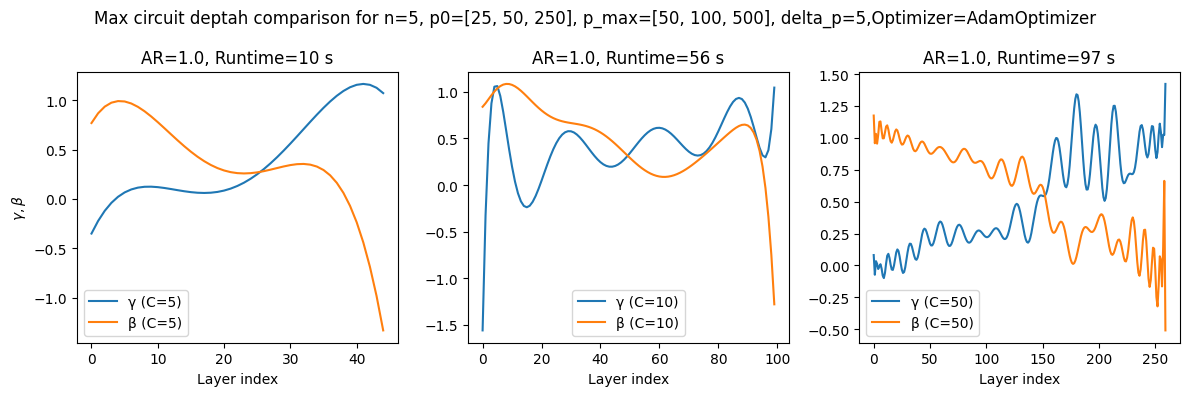

In [3]:
result_AR = [np.round(np.real_if_close(AR)) for AR in result_AR]
runtimes_II = [int(runtime) for runtime in runtimes_II]

fig, ax = plt.subplots(ncols=3, figsize=(12, 4))

fig.suptitle(
    f'Max circuit deptah comparison for n={n}, p0={p0_vals}, p_max={p_max_vals}, delta_p={delta_p},'
    f'Optimizer={qml.AdamOptimizer.__name__}'
    #f'Optimizer comparison for n={n}, p0={p0}, dp=5, p_max={p}, '
    #f'epsilon=0.1, tau=10, opt_steps=100, stepsize={stepsize}'
)

for i in range(len(p_max_vals)):
    # Axis labels
    ax[i].set_xlabel('Layer index')
    ax[i].set_title(f'AR={result_AR[i]}, Runtime={runtimes_II[i]} s')

    if i == 0:
        ax[i].set_ylabel(r'$\gamma, \beta$')
    layers = np.arange(len(result_gammas[i]))
    ax[i].plot(layers, result_gammas[i], linestyle='-', label=f'γ (C={C_vals[i]})')
    ax[i].plot(layers, result_betas[i], linestyle='-', label=f'β (C={C_vals[i]})')

    ax[i].legend()

plt.tight_layout()
plt.show()